In [1]:
import os
import glob

import anndata
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import scipy.sparse as sp
import seaborn as sns
import torch

/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]
extended_colors = [
    '#2E2A3A',
    '#FF8DAF', '#FF1B5E',
    '#FFEDA0', '#FFDB57',
    '#A4C8FE', '#438CFD',
    '#FFCF80', '#FF8C00',
    '#C4F9AE', '#80F15E',
    '#A0FFFF', '#03FFFF',
    '#A99FD4', '#5941A9',
    '#F4BFFE', '#E980FC',
    '#E8E4F0', '#C4BDD6',
    '#E8C89A', '#C17F3E'
]

In [3]:
worms = pd.read_csv('../results/worm6_final/DNA_analysis/obs.csv', index_col=0)['donor'].sort_values().unique().tolist()
pal = {worm: extended_colors[i] for i, worm in enumerate(worms)}

In [4]:
fm._load_fontmanager(try_read_cache=False)
for f in glob.glob(os.path.expanduser('~/.local/share/fonts/texgyreheros*.otf')):
    fm.fontManager.addfont(f)

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['TeX Gyre Heros'],
    'font.size': 12,
    'axes.linewidth': 2.5,
    'xtick.major.width': 2.5,
    'ytick.major.width': 2.5,
    'xtick.minor.width': 2.0,
    'ytick.minor.width': 2.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})

In [5]:
scvi.settings.seed = 0
print('Last run with scvi-tools version:', scvi.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using: {device}')

[rank: 0] Seed set to 0


Last run with scvi-tools version: 1.4.1
using: cuda


# Read counts

In [27]:
adata = sc.read_h5ad('../CapGTA_dev/results/worm6_final/adata_gex_splicedpolyat_soupx_processed.h5ad')
data = pd.read_csv('/fh/working/srivatsan_s/Dustin/worm6-dubnova-100k-align/pooled_sc_qc_metrics.csv', index_col='barcode')
adata.obs = pd.concat([adata.obs, data.loc[adata.obs_names]], axis=1)
adata.obs['poly_at'] = pd.read_csv('../results/worm6_final/DNA_analysis/polyat_counts_per_cell.csv', index_col=0)
adata.obs['genomic_reads'] = adata.obs['unique_aligned_reads'] - (adata.obs['splice_reads'] + adata.obs['poly_at'])
adata.obs['transcriptomic_reads'] = adata.obs['splice_reads'] + adata.obs['poly_at']

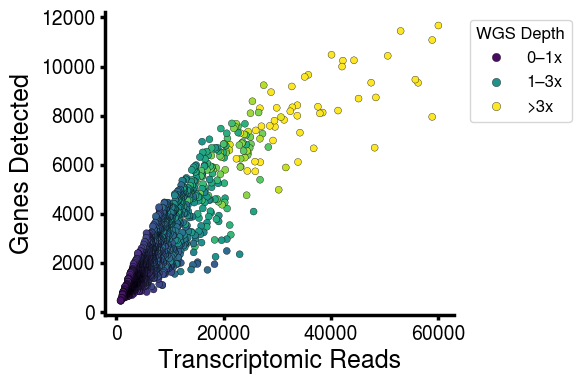

In [28]:
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

data = adata.obs.sort_values('total_counts', ascending=False).iloc[1:]

norm = Normalize(vmin=0, vmax=3, clip=True)
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.scatterplot(
    data=data,
    x="total_counts",
    y="genes_detected",
    hue="mean_coverage",
    hue_norm=norm,
    palette=cmap,
    ec="black",
    linewidth=0.25,
    s=25,
    zorder=3,
    legend=False,
    ax=ax,
)

# representative value per bin -> color straight from the mapping
reps   = [0.1, 1.5, 3.0]                     # 3.0 clips to the top -> full yellow
labels = ["0–1x", "1–3x", ">3x"]

handles = [
    Line2D([], [], marker="o", linestyle="none", markersize=6,
           markerfacecolor=cmap(norm(v)), markeredgecolor="black",
           markeredgewidth=0.25, label=lab)
    for v, lab in zip(reps, labels)
]

ax.set_xlabel("Transcriptomic Reads", fontsize=18)
ax.set_ylabel("Genes Detected", fontsize=18)
ax.tick_params(labelsize=14)
ax.legend(handles=handles, title="WGS Depth",
          fontsize=12, title_fontsize=12, bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()

plt.savefig("../results/worm6_final/figures/coassay_readcount_scatter.png", dpi=600, bbox_inches="tight")

In [29]:
ref = sc.read_h5ad('../data/references/cengen_L4/taylor2020.h5ad')
ref.var_names = ref.var['gene_name']
ref.layers["counts"] = ref.X.copy()
ref

AnnData object with n_obs × n_vars = 100955 × 22469
    obs: 'study', 'sample_batch', 'sample', 'sample_description', 'barcode', 'cell_type', 'cell_subtype'
    var: 'gene_id', 'gene_name'
    layers: 'counts'

In [30]:
ref = ref[:,ref.var_names.isin(adata.var_names)].copy()
# ref[:,ref.var_names.isin(adata.var['wormbase_id'].values)]

In [31]:
ref.var[['exonic_length', 'n_junctions']] = adata.var.loc[ref.var_names][['exonic_length', 'n_junctions']]

In [32]:
sc.pp.calculate_qc_metrics(ref, inplace=True)

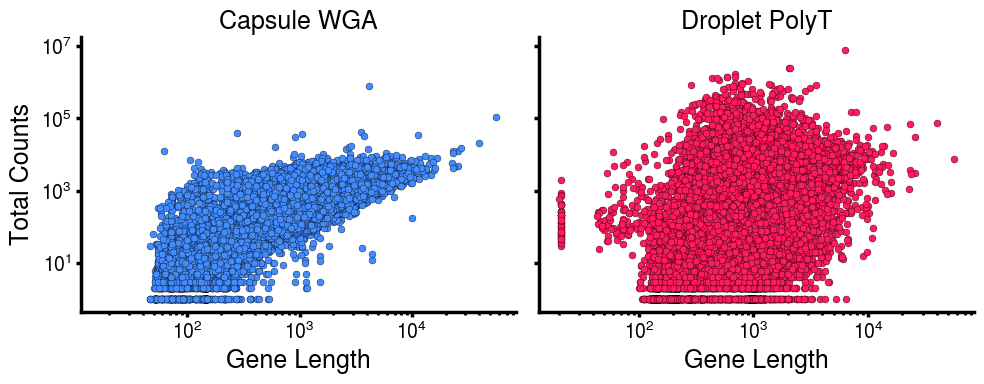

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
c = {'Capsule WGA': colors[2], 'Droplet PolyT':colors[0]}
for ax, var, title in zip(axes, [adata.var, ref.var], ["Capsule WGA", "Droplet PolyT"]):
    sns.scatterplot(
        data=var,
        x="exonic_length",
        y="total_counts",
        color=c[title],
        s=25,
        ec="black",
        linewidth=0.25,
        zorder=3,
        legend=False,
        ax=ax,
    )
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel("Gene Length", fontsize=18)
    ax.set_title(title, fontsize=18)
    ax.tick_params(labelsize=14)

axes[0].set_ylabel("Total Counts", fontsize=18)
axes[1].set_ylabel("")  # hide duplicate y-label on right panel

sns.despine()
plt.tight_layout()

plt.savefig("../results/worm6_final/figures/readcount_dist_vs_ref.png", dpi=600, bbox_inches="tight")

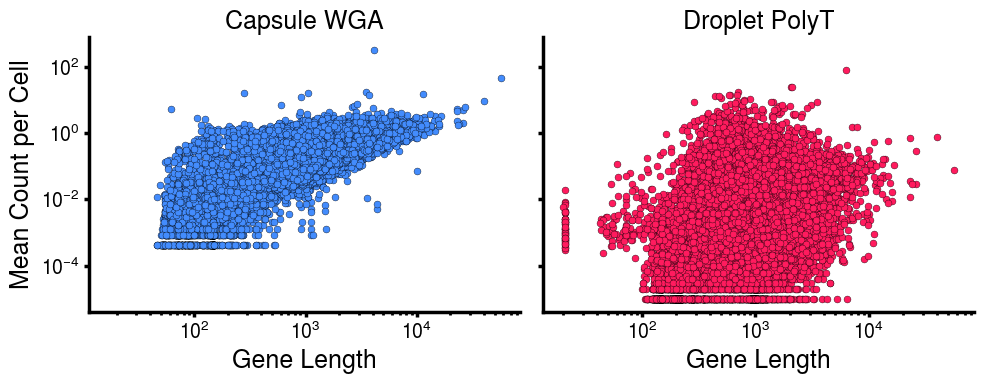

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, var, title in zip(axes, [adata.var, ref.var], ["Capsule WGA", "Droplet PolyT"]):
    sns.scatterplot(
        data=var,
        x="exonic_length",
        y="mean_counts",
        color=c[title],
        s=25,
        ec="black",
        linewidth=0.25,
        zorder=3,
        legend=False,
        ax=ax,
    )
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel("Gene Length", fontsize=18)
    ax.set_title(title, fontsize=18)
    ax.tick_params(labelsize=14)

axes[0].set_ylabel("Mean Count per Cell", fontsize=18)
axes[1].set_ylabel("")  # hide duplicate y-label on right panel

sns.despine()
plt.tight_layout()

plt.savefig("../results/worm6_final/figures/readcount_dist_vs_ref_percell.png", dpi=600, bbox_inches="tight")

# Coembedding

In [37]:
adata = sc.read_h5ad('../results/worm6_final/GEX/adata_gex_splicedpolyat.h5ad')
adata.var_names = adata.var['wormbase_id'].astype(str).values
adata = adata[:, ~adata.var_names.duplicated()].copy()
adata

AnnData object with n_obs × n_vars = 2404 × 46748
    obs: 'total_counts', 'genes_detected', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'assay', 'leiden'
    var: 'wormbase_id', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_junctions', 'exonic_length', 'detectability_k', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [38]:
joint = sc.read_h5ad('../results/worm6_final/DNA_analysis/joint_variants_process.h5ad', backed='r')
adata.obs['donor'] = joint.obs['donor'].reindex(adata.obs_names).values
adata = adata[~adata.obs['donor'].astype(str).isin(['worm02', 'worm04', 'worm14', 'worm19', 'background'])].copy()
adata.obs['donor'].value_counts()

donor
worm07    186
worm12    152
worm20    146
worm01    141
worm10    132
worm05    123
worm16    121
worm09    114
worm18    106
worm06    103
worm15     90
worm11     87
worm03     81
worm17     71
worm08     70
worm13     52
Name: count, dtype: int64

In [41]:
query = adata.copy()
query.obs['cell_type'] = 'Unannotated'

In [39]:
ref = sc.read_h5ad('../results/worm6_final/reference_degradation/degraded_seeds/taylor2020_degraded_seed0.h5ad')
ref.layers['counts'] = ref.X.copy()
ref

AnnData object with n_obs × n_vars = 31937 × 22469
    obs: 'study', 'sample_batch', 'sample', 'sample_description', 'barcode', 'cell_type', 'cell_subtype', 'anchor_tissue'
    var: 'gene_id', 'gene_name', 'p_g_pooled'
    uns: 'degradation_config'
    layers: 'counts'

In [42]:
sc.pp.highly_variable_genes(query, flavor='seurat_v3', n_top_genes=5000, layer='counts')
hvg = query.var_names[query.var['highly_variable']]
len(hvg)

5000

In [43]:
common = ref.var_names.intersection(query.var_names).intersection(hvg)
ref_sub = ref[:, common].copy()
query_sub = query[:, common].copy()
len(common)

2919

In [44]:
adata_concat = anndata.concat(
    [ref_sub, query_sub],
    label='assay',
    keys=['CENGEN', 'CapGTA'],
    merge='unique',
)
adata_concat.layers['counts'] = sp.vstack([
    ref_sub.layers['counts'].tocsr() if sp.issparse(ref_sub.layers['counts']) else sp.csr_matrix(ref_sub.layers['counts']),
    query_sub.layers['counts'].tocsr() if sp.issparse(query_sub.layers['counts']) else sp.csr_matrix(query_sub.layers['counts']),
]).tocsr()
adata_concat.X = adata_concat.layers['counts'].copy()
print(adata_concat.obs['assay'].value_counts())
adata_concat

assay
CENGEN    31937
CapGTA     1775
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 33712 × 2919
    obs: 'cell_type', 'assay'
    var: 'gene_id', 'gene_name', 'p_g_pooled', 'n_cells', 'wormbase_id', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_junctions', 'exonic_length', 'detectability_k', 'dispersions', 'dispersions_norm'
    varm: 'PCs'
    layers: 'counts'

### `scVI`

In [45]:
scvi.model.SCVI.setup_anndata(adata_concat, layer='counts', batch_key='assay')

In [46]:
scvi_model = scvi.model.SCVI(adata_concat, n_latent=30, n_layers=2, dispersion='gene-batch')

In [ ]:
scvi_model.train(max_epochs=400, early_stopping=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/dmullane/micromamba/envs/scvi-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argumen

Epoch 140/400:  35%|███▍      | 139/400 [07:23<14:27,  3.32s/it, v_num=1, train_loss=351]

In [ ]:
SCVI_LATENT_KEY = 'X_scVI'
adata_concat.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()
sc.pp.neighbors(adata_concat, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata_concat, min_dist=0.3)

In [ ]:
scvi_model.history['elbo_train'].iloc[10:].plot(logy=True)
plt.show()

In [ ]:
sc.pl.umap(adata_concat, color=['assay'], frameon=False, ncols=1)

### `scANVI`

In [ ]:
SCANVI_CELLTYPE_KEY = 'celltype_scanvi'
adata_concat.obs[SCANVI_CELLTYPE_KEY] = 'Unknown'
ref_mask = adata_concat.obs['assay'] == 'cengen_taylor2020'
adata_concat.obs.loc[ref_mask, SCANVI_CELLTYPE_KEY] = adata_concat.obs.loc[ref_mask, 'cell_type'].astype(str).values

In [ ]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    adata=adata_concat,
    unlabeled_category='Unknown',
    labels_key=SCANVI_CELLTYPE_KEY,
)

In [ ]:
scanvi_model.train(max_epochs=50, early_stopping=True)

In [ ]:
SCANVI_LATENT_KEY = 'X_scANVI'
SCANVI_PREDICTION_KEY = 'C_scANVI'
adata_concat.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation()
adata_concat.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict()

In [ ]:
# sc.pp.neighbors(adata_concat, use_rep=SCANVI_LATENT_KEY)
# sc.tl.umap(adata_concat, min_dist=0.3)

In [ ]:
# sc.pl.umap(adata_concat, color=['assay', SCANVI_PREDICTION_KEY], frameon=False, ncols=1)

# Save

In [ ]:
adata_concat.write_h5ad('../CapGTA_dev/results/worm6_final/adata_gex_scanvi_asymmetric.h5ad')